<a href="https://colab.research.google.com/github/prithyanga-s/Predictive-Analytics-Historical-Data/blob/main/Predictive_Analytics_Historical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    'Month': [
        '2023-01','2023-02','2023-03','2023-04','2023-05','2023-06',
        '2023-07','2023-08','2023-09','2023-10','2023-11','2023-12',
        '2024-01','2024-02','2024-03','2024-04','2024-05','2024-06',
        '2024-07','2024-08','2024-09','2024-10','2024-11','2024-12'
    ],
    'Sales': [
        12000,13500,14200,15000,15800,16500,
        17200,18000,17600,19000,20500,22000,
        21500,22800,24000,25200,26500,27800,
        29000,30200,29500,31500,33000,35000
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")

Dataset created successfully!


In [3]:
df.head()

,Month,Sales
0,2023-01,12000
1,2023-02,13500
2,2023-03,14200
3,2023-04,15000
4,2023-05,15800


In [4]:
df

,Month,Sales
0,2023-01,12000
1,2023-02,13500
2,2023-03,14200
3,2023-04,15000
4,2023-05,15800
5,2023-06,16500
6,2023-07,17200
7,2023-08,18000
8,2023-09,17600
9,2023-10,19000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   24 non-null     object
 1   Sales   24 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 516.0+ bytes


In [6]:
df.describe()

,Sales
count,24.000000
mean,22387.500000
std,6719.815765
min,12000.000000
25%,17025.000000
50%,21750.000000
75%,28100.000000
max,35000.000000


In [7]:
df.isnull().sum()

,0
Month,0
Sales,0


In [8]:
df['Month'] = pd.to_datetime(df['Month'])

df.head()

,Month,Sales
0,2023-01-01,12000
1,2023-02-01,13500
2,2023-03-01,14200
3,2023-04-01,15000
4,2023-05-01,15800


In [9]:
df['Time'] = np.arange(len(df))

df.head()

,Month,Sales,Time
0,2023-01-01,12000,0
1,2023-02-01,13500,1
2,2023-03-01,14200,2
3,2023-04-01,15000,3
4,2023-05-01,15800,4


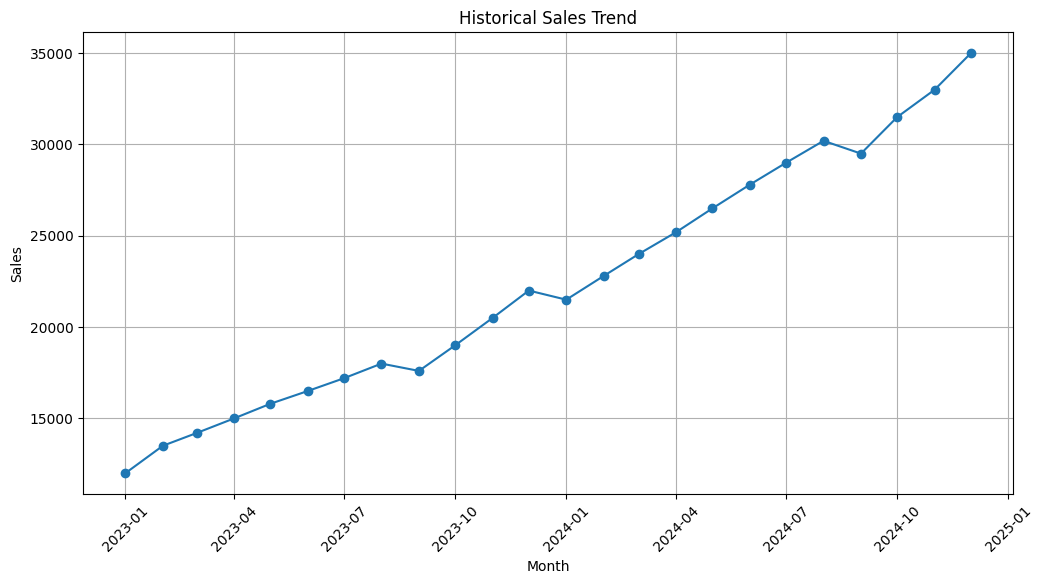

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df['Month'], df['Sales'], marker='o')

plt.title('Historical Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

In [12]:
X = df[['Time']]
y = df['Sales']

In [13]:
X_train = X.iloc[:18]
X_test = X.iloc[18:]

y_train = y.iloc[:18]
y_test = y.iloc[18:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 18
Testing data: 6


In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
y_pred = model.predict(X_test)

print(y_pred)

[27595.4248366  28458.68593051 29321.94702442 30185.20811834
 31048.46921225 31911.73030616]


In [16]:
comparison = pd.DataFrame({
    'Month': df['Month'].iloc[18:],
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison

,Month,Actual Sales,Predicted Sales
18,2024-07-01,29000,27595.424837
19,2024-08-01,30200,28458.685931
20,2024-09-01,29500,29321.947024
21,2024-10-01,31500,30185.208118
22,2024-11-01,33000,31048.469212
23,2024-12-01,35000,31911.730306


In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1613.089095287239
Mean Squared Error: 3351878.1249818853
Root Mean Squared Error: 1830.8135145289607
R² Score: 0.23628093354843127


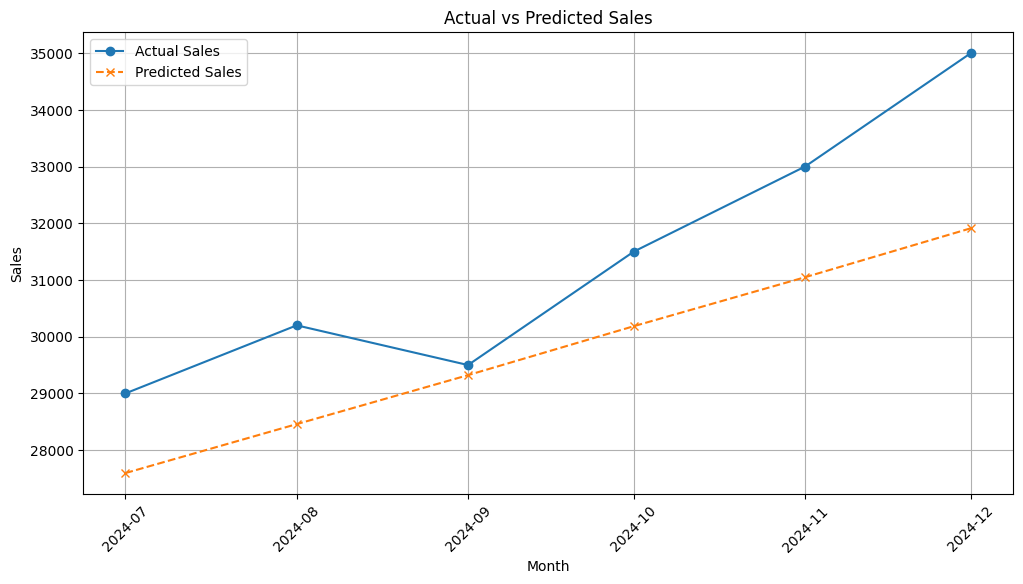

In [18]:
plt.figure(figsize=(12,6))

plt.plot(df['Month'].iloc[18:], y_test.values,
         marker='o', label='Actual Sales')

plt.plot(df['Month'].iloc[18:], y_pred,
         marker='x', linestyle='--', label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [19]:
future_time = np.arange(len(df), len(df) + 6).reshape(-1, 1)

future_predictions = model.predict(future_time)

future_predictions

array([32774.99140007, 33638.25249398, 34501.51358789, 35364.7746818 ,
       36228.03577571, 37091.29686963])

In [20]:
future_dates = pd.date_range(
    start=df['Month'].iloc[-1] + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)

In [21]:
future_df = pd.DataFrame({
    'Month': future_dates,
    'Predicted Sales': future_predictions
})

future_df

,Month,Predicted Sales
0,2025-01-01,32774.991400
1,2025-02-01,33638.252494
2,2025-03-01,34501.513588
3,2025-04-01,35364.774682
4,2025-05-01,36228.035776
5,2025-06-01,37091.296870


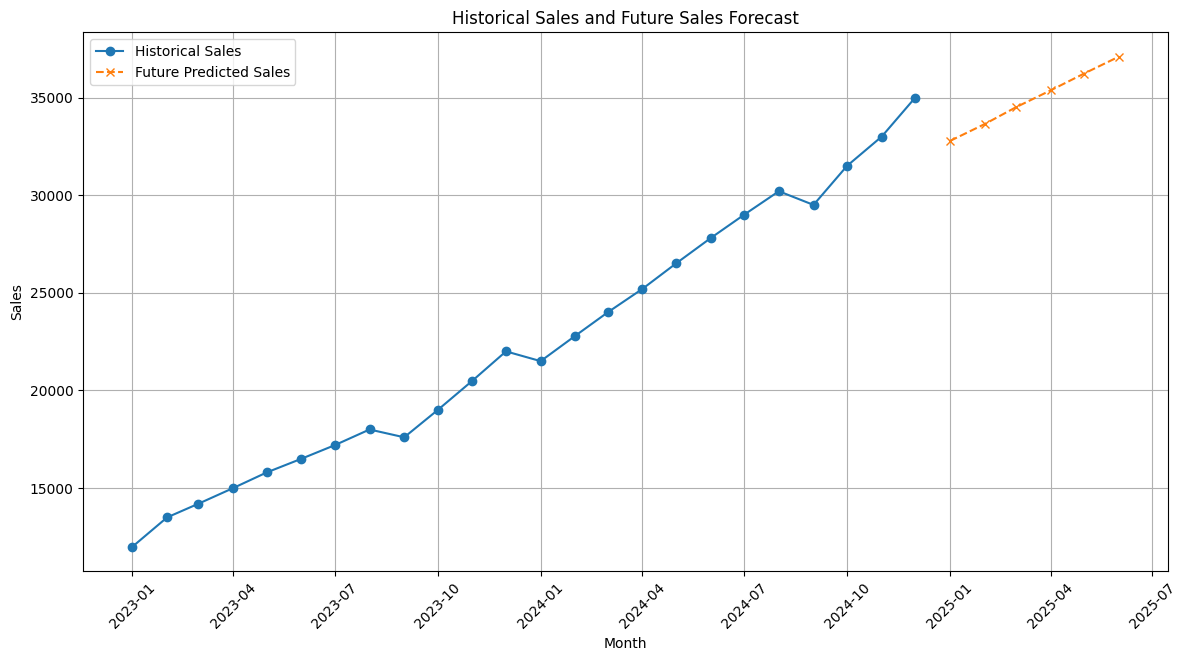

In [22]:
plt.figure(figsize=(14,7))

plt.plot(
    df['Month'],
    df['Sales'],
    marker='o',
    label='Historical Sales'
)

plt.plot(
    future_df['Month'],
    future_df['Predicted Sales'],
    marker='x',
    linestyle='--',
    label='Future Predicted Sales'
)

plt.title('Historical Sales and Future Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [23]:
future_df.to_csv('future_sales_predictions.csv', index=False)

print("Prediction file saved successfully!")

Prediction file saved successfully!


In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create Polynomial Regression model
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

# Train the model
poly_model.fit(X_train, y_train)

# Make predictions
poly_pred = poly_model.predict(X_test)

# Evaluate the model
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_pred)

print("Polynomial Regression Results")
print("--------------------------------")
print("MAE :", poly_mae)
print("MSE :", poly_mse)
print("RMSE:", poly_rmse)
print("R² Score:", poly_r2)

Polynomial Regression Results
--------------------------------
MAE : 620.9881320949438
MSE : 547417.1605414505
RMSE: 739.8764495113022
R² Score: 0.8752720393703024


In [25]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression'
    ],
    'MAE': [
        mae,
        poly_mae
    ],
    'RMSE': [
        rmse,
        poly_rmse
    ],
    'R2 Score': [
        r2,
        poly_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1613.089095,1830.813515,0.236281
1,Polynomial Regression,620.988132,739.876450,0.875272


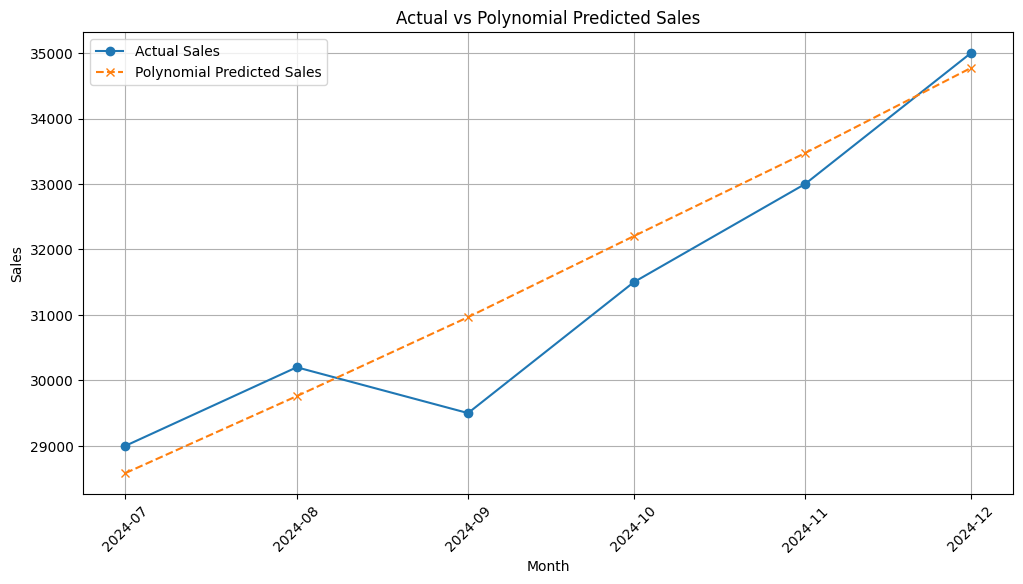

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    df['Month'].iloc[18:],
    y_test.values,
    marker='o',
    label='Actual Sales'
)

plt.plot(
    df['Month'].iloc[18:],
    poly_pred,
    marker='x',
    linestyle='--',
    label='Polynomial Predicted Sales'
)

plt.title('Actual vs Polynomial Predicted Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [27]:
future_poly_predictions = poly_model.predict(future_time)

future_poly_df = pd.DataFrame({
    'Month': future_dates,
    'Predicted Sales': future_poly_predictions
})

future_poly_df

,Month,Predicted Sales
0,2025-01-01,36103.508772
1,2025-02-01,37466.047472
2,2025-03-01,38859.791022
3,2025-04-01,40284.739422
4,2025-05-01,41740.892673
5,2025-06-01,43228.250774


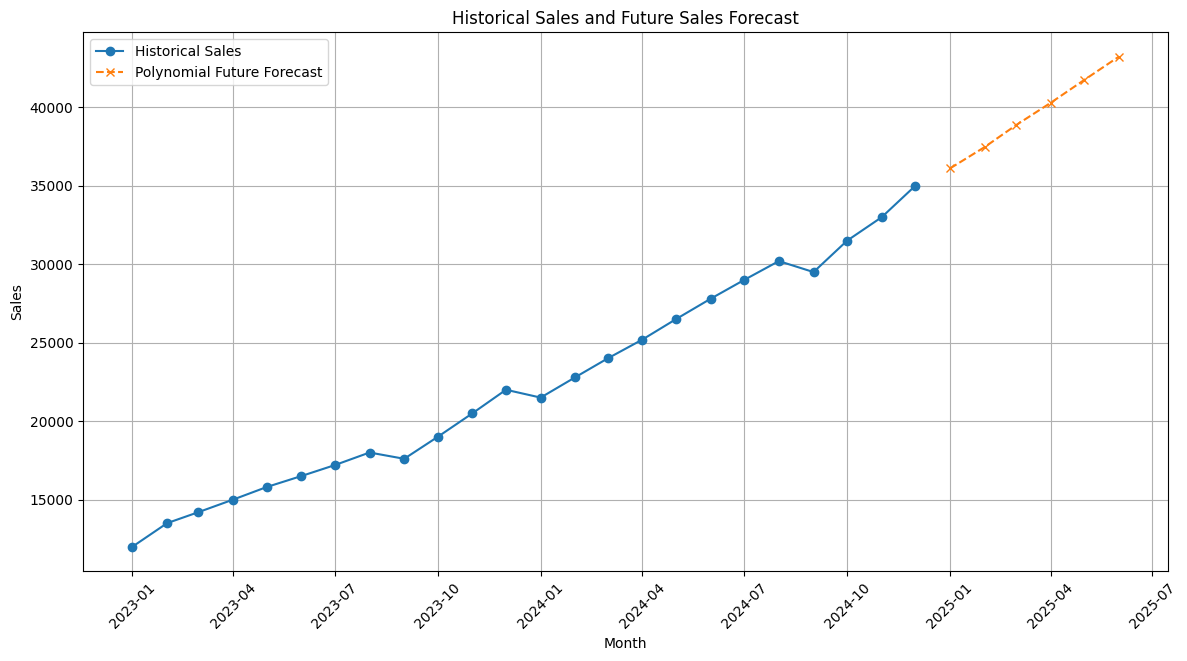

In [28]:
plt.figure(figsize=(14,7))

plt.plot(
    df['Month'],
    df['Sales'],
    marker='o',
    label='Historical Sales'
)

plt.plot(
    future_poly_df['Month'],
    future_poly_df['Predicted Sales'],
    marker='x',
    linestyle='--',
    label='Polynomial Future Forecast'
)

plt.title('Historical Sales and Future Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [29]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Regression Results
--------------------------------
MAE : 4172.666666666667
MSE : 21800036.0
RMSE: 4669.050867146341
R² Score: -3.9670968101265816


In [30]:
final_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Random Forest Regression'
    ],
    'MAE': [
        mae,
        poly_mae,
        rf_mae
    ],
    'RMSE': [
        rmse,
        poly_rmse,
        rf_rmse
    ],
    'R2 Score': [
        r2,
        poly_r2,
        rf_r2
    ]
})

final_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1613.089095,1830.813515,0.236281
1,Polynomial Regression,620.988132,739.876450,0.875272
2,Random Forest Regression,4172.666667,4669.050867,-3.967097


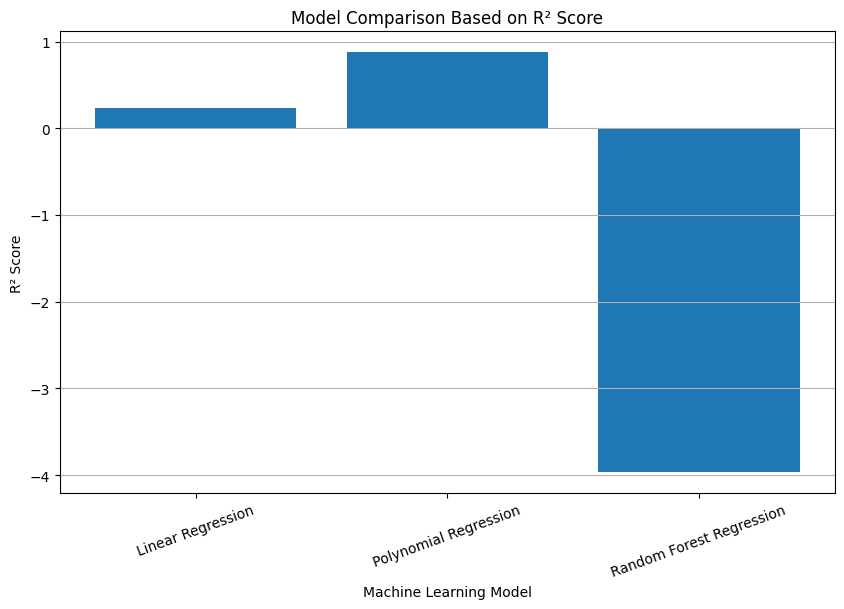

In [31]:
plt.figure(figsize=(10,6))

plt.bar(
    final_comparison['Model'],
    final_comparison['R2 Score']
)

plt.title('Model Comparison Based on R² Score')
plt.xlabel('Machine Learning Model')
plt.ylabel('R² Score')

plt.xticks(rotation=20)
plt.grid(axis='y')

plt.show()

In [32]:
print("==============================================")
print("       PREDICTIVE ANALYTICS SUMMARY")
print("==============================================")

print("\nDataset Information")
print("--------------------")
print("Total historical records:", len(df))
print("Historical period:",
      df['Month'].min().strftime('%B %Y'),
      "to",
      df['Month'].max().strftime('%B %Y'))

print("\nModel Performance")
print("-----------------")
print("Linear Regression R²:", round(r2, 3))
print("Polynomial Regression R²:", round(poly_r2, 3))
print("Random Forest R²:", round(rf_r2, 3))

print("\nFuture Sales Forecast")
print("---------------------")
for i in range(len(future_poly_df)):
    print(
        future_poly_df['Month'].iloc[i].strftime('%B %Y'),
        "->",
        round(future_poly_df['Predicted Sales'].iloc[i], 2)
    )

       PREDICTIVE ANALYTICS SUMMARY

Dataset Information
--------------------
Total historical records: 24
Historical period: January 2023 to December 2024

Model Performance
-----------------
Linear Regression R²: 0.236
Polynomial Regression R²: 0.875
Random Forest R²: -3.967

Future Sales Forecast
---------------------
January 2025 -> 36103.51
February 2025 -> 37466.05
March 2025 -> 38859.79
April 2025 -> 40284.74
May 2025 -> 41740.89
June 2025 -> 43228.25


In [33]:
average_sales = df['Sales'].mean()
maximum_sales = df['Sales'].max()
minimum_sales = df['Sales'].min()

max_month = df.loc[df['Sales'].idxmax(), 'Month']
min_month = df.loc[df['Sales'].idxmin(), 'Month']

print("Sales Statistics")
print("----------------")
print("Average Sales:", round(average_sales, 2))
print("Maximum Sales:", maximum_sales)
print("Maximum Sales Month:", max_month.strftime('%B %Y'))
print("Minimum Sales:", minimum_sales)
print("Minimum Sales Month:", min_month.strftime('%B %Y'))

Sales Statistics
----------------
Average Sales: 22387.5
Maximum Sales: 35000
Maximum Sales Month: December 2024
Minimum Sales: 12000
Minimum Sales Month: January 2023


In [34]:
first_sales = df['Sales'].iloc[0]
last_sales = df['Sales'].iloc[-1]

growth_percentage = ((last_sales - first_sales) / first_sales) * 100

print("Sales Growth Analysis")
print("---------------------")
print("Initial Sales:", first_sales)
print("Final Sales:", last_sales)
print("Overall Growth:", round(growth_percentage, 2), "%")

Sales Growth Analysis
---------------------
Initial Sales: 12000
Final Sales: 35000
Overall Growth: 191.67 %


In [35]:
final_forecast = future_poly_df.copy()

final_forecast['Predicted Sales'] = final_forecast['Predicted Sales'].round(2)

final_forecast

,Month,Predicted Sales
0,2025-01-01,36103.51
1,2025-02-01,37466.05
2,2025-03-01,38859.79
3,2025-04-01,40284.74
4,2025-05-01,41740.89
5,2025-06-01,43228.25


In [36]:
final_forecast.to_csv(
    'final_future_sales_forecast.csv',
    index=False
)

print("Final forecast saved successfully!")

Final forecast saved successfully!


# Conclusion

This project demonstrates the use of predictive analytics to forecast future sales using historical data. The dataset was cleaned and preprocessed before performing trend analysis and visualization.

Linear Regression, Polynomial Regression, and Random Forest Regression models were developed and evaluated using MAE, RMSE, and R² score.

The Polynomial Regression model achieved an R² score of approximately 0.875 on the selected test data and was used to generate the illustrative future sales forecast. The analysis shows an overall increasing trend in historical sales and provides estimated sales values for the following six months.

The project demonstrates how historical data can be transformed into useful predictions using machine learning techniques. However, the dataset used in this demonstration is small, so the forecasts should be treated as illustrative rather than production-level business predictions.

# Future Scope

- Use a larger real-world sales dataset.
- Include additional features such as price, advertising expenditure, product category, holidays, and customer demand.
- Apply advanced time-series models such as ARIMA, SARIMA, or Prophet.
- Perform hyperparameter tuning for machine learning models.
- Build an interactive dashboard for sales forecasting.
- Deploy the predictive model as a web application.
- Update predictions automatically when new sales data becomes available.